### Logistic Regression

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, classification_report, 
                            log_loss, roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded!")

Libraries loaded!


In [9]:
# Create synthetic customer purchase data
X, y = make_classification(
    n_samples=1000,           # 1000 customers
    n_features=3,             # 3 features
    n_informative=3,          # All features useful
    n_redundant=0,
    n_classes=2,
    random_state=42
)

# Create dataframe for better viewing
feature_names = ['Age', 'Income', 'Visits']
df = pd.DataFrame(X, columns=feature_names)
df['Purchased'] = y

print("Dataset created!")
print(f"Shape: {df.shape}")
print(f"\nFirst 5 customers:")
print(df.head())

print(f"\n Target Distribution:")
print(df['Purchased'].value_counts())
print(f"0 = Did NOT purchase ({df['Purchased'].value_counts()[0]})")
print(f"1 = Purchased ({df['Purchased'].value_counts()[1]})")

Dataset created!
Shape: (1000, 4)

First 5 customers:
        Age    Income    Visits  Purchased
0  0.521706  0.726857  2.504102          1
1 -1.019710 -0.749860 -0.713463          0
2 -1.892225 -1.032171  1.541761          0
3  0.625801 -0.866283 -0.350923          0
4  1.034612  1.641388  3.182540          1

 Target Distribution:
Purchased
0    501
1    499
Name: count, dtype: int64
0 = Did NOT purchase (501)
1 = Purchased (499)


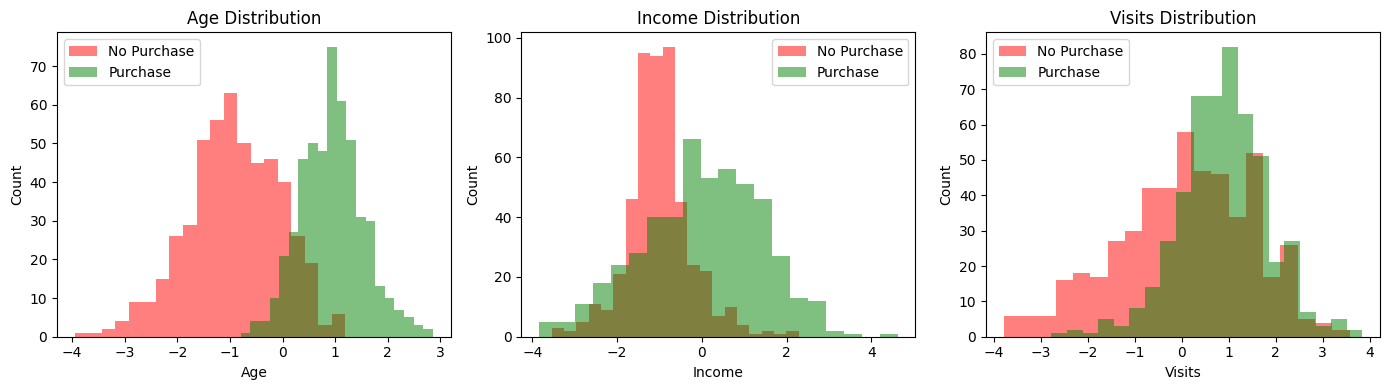

 Green = Purchased, Red = Did not purchase
If green and red are well separated → Feature is useful!


In [10]:
# Simple scatter plot to see patterns
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Plot each feature against target
for i, feature in enumerate(feature_names):
    ax = axes[i]
    # Separate by purchase status
    no_purchase = df[df['Purchased'] == 0][feature]
    yes_purchase = df[df['Purchased'] == 1][feature]
    
    # Histograms
    ax.hist(no_purchase, alpha=0.5, label='No Purchase', color='red', bins=20)
    ax.hist(yes_purchase, alpha=0.5, label='Purchase', color='green', bins=20)
    ax.set_xlabel(feature)
    ax.set_ylabel('Count')
    ax.set_title(f'{feature} Distribution')
    ax.legend()

plt.tight_layout()
plt.show()

print(" Green = Purchased, Red = Did not purchase")
print("If green and red are well separated → Feature is useful!")

In [11]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train model
model = LogisticRegression()
model.fit(X_train, y_train)

# Make predictions (probabilities)
y_prob = model.predict_proba(X_test)[:, 1]  # Probability of "Yes"
y_pred = model.predict(X_test)              # Binary prediction (0 or 1)

print(" MODEL TRAINED!")
print("="*50)
print("Model Formula:")
print("z = ", end="")
for i, feat in enumerate(feature_names):
    coef = model.coef_[0][i]
    if coef > 0:
        print(f" + {coef:.3f}×{feat}", end="")
    else:
        print(f" {coef:.3f}×{feat}", end="")
print(f" + {model.intercept_[0]:.3f}")
print("\nThen: Probability = 1 / (1 + e^(-z))")
print("Decision: If Probability >= 0.5 → Purchase")

 MODEL TRAINED!
Model Formula:
z =  + 3.403×Age + 0.713×Income + 0.336×Visits + 0.098

Then: Probability = 1 / (1 + e^(-z))
Decision: If Probability >= 0.5 → Purchase


In [12]:
# Calculate metrics
log_loss_score = log_loss(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

print("MODEL PERFORMANCE METRICS")
print("="*50)
print(f"Log-Loss: {log_loss_score:.4f}")
print(f"  (0=perfect, 0.693=random guessing, higher=worse)")
print(f"\nROC-AUC Score: {auc_score:.4f}")
print(f"  (0.5=random, 1.0=perfect, >0.8=good)")
print("\n" + "="*50)

# Classification Report
print("\nCLASSIFICATION REPORT:")
print("="*50)
print(classification_report(y_test, y_pred, 
                          target_names=['No Purchase', 'Purchase']))

print("\nUnderstanding the metrics:")
print("Precision = Of all 'Purchase' predictions, how many were correct?")
print("Recall    = Of all actual 'Purchases', how many did we catch?")
print("F1-Score  = Harmonic mean of Precision and Recall")

MODEL PERFORMANCE METRICS
Log-Loss: 0.2293
  (0=perfect, 0.693=random guessing, higher=worse)

ROC-AUC Score: 0.9680
  (0.5=random, 1.0=perfect, >0.8=good)


CLASSIFICATION REPORT:
              precision    recall  f1-score   support

 No Purchase       0.92      0.91      0.91       110
    Purchase       0.89      0.90      0.90        90

    accuracy                           0.91       200
   macro avg       0.90      0.90      0.90       200
weighted avg       0.91      0.91      0.91       200


Understanding the metrics:
Precision = Of all 'Purchase' predictions, how many were correct?
Recall    = Of all actual 'Purchases', how many did we catch?
F1-Score  = Harmonic mean of Precision and Recall


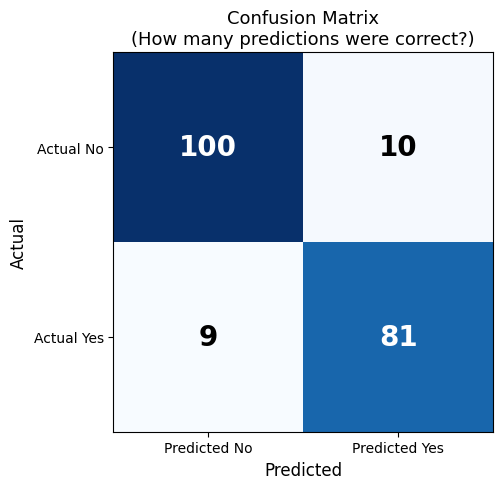


📌 INTERPRETATION:
Correct Predictions: 181 (Diagonal)
Wrong Predictions: 19 (Off-diagonal)

True Negatives (TN) = 100 (Correctly predicted NO)
True Positives (TP) = 81 (Correctly predicted YES)
False Positives (FP) = 10 (False alarms)
False Negatives (FN) = 9 (Missed opportunities)


In [13]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot simple confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))

# Create colored grid
im = ax.imshow(cm, cmap='Blues', interpolation='nearest')

# Add values
for i in range(2):
    for j in range(2):
        text = ax.text(j, i, cm[i, j],
                      ha="center", va="center",
                      color="white" if cm[i, j] > cm.max()/2 else "black",
                      fontsize=20, fontweight='bold')

# Labels
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted No', 'Predicted Yes'])
ax.set_yticklabels(['Actual No', 'Actual Yes'])
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix\n(How many predictions were correct?)', fontsize=13)

plt.tight_layout()
plt.show()

print("\n📌 INTERPRETATION:")
print(f"Correct Predictions: {cm[0,0] + cm[1,1]} (Diagonal)")
print(f"Wrong Predictions: {cm[0,1] + cm[1,0]} (Off-diagonal)")
print(f"\nTrue Negatives (TN) = {cm[0,0]} (Correctly predicted NO)")
print(f"True Positives (TP) = {cm[1,1]} (Correctly predicted YES)")
print(f"False Positives (FP) = {cm[0,1]} (False alarms)")
print(f"False Negatives (FN) = {cm[1,0]} (Missed opportunities)")

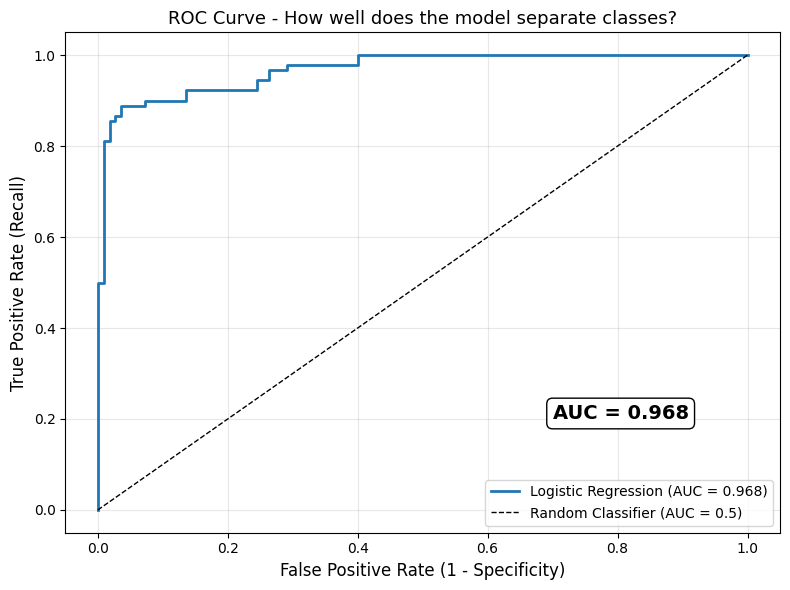


INTERPRETATION:
AUC = 0.968
Excellent model! (AUC > 0.9)

What this tells us:
The closer the curve is to the top-left corner, the better!
Your model is 96.8% accurate at separating classes.


In [14]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Plot ROC curve
plt.figure(figsize=(8, 6))

# ROC Curve
plt.plot(fpr, tpr, linewidth=2, label=f'Logistic Regression (AUC = {auc_score:.3f})')

# Random classifier line
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5)')

# Labels and title
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve - How well does the model separate classes?', fontsize=13)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

# Add AUC value in the plot
plt.text(0.7, 0.2, f'AUC = {auc_score:.3f}', 
         bbox=dict(boxstyle="round", facecolor='white', edgecolor='black'),
         fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nINTERPRETATION:")
print(f"AUC = {auc_score:.3f}")
if auc_score > 0.9:
    print("Excellent model! (AUC > 0.9)")
elif auc_score > 0.8:
    print("Good model! (AUC > 0.8)")
elif auc_score > 0.7:
    print("Fair model (AUC > 0.7)")
else:
    print("Poor model (AUC < 0.7)")

print("\nWhat this tells us:")
print("The closer the curve is to the top-left corner, the better!")
print(f"Your model is {auc_score*100:.1f}% accurate at separating classes.")

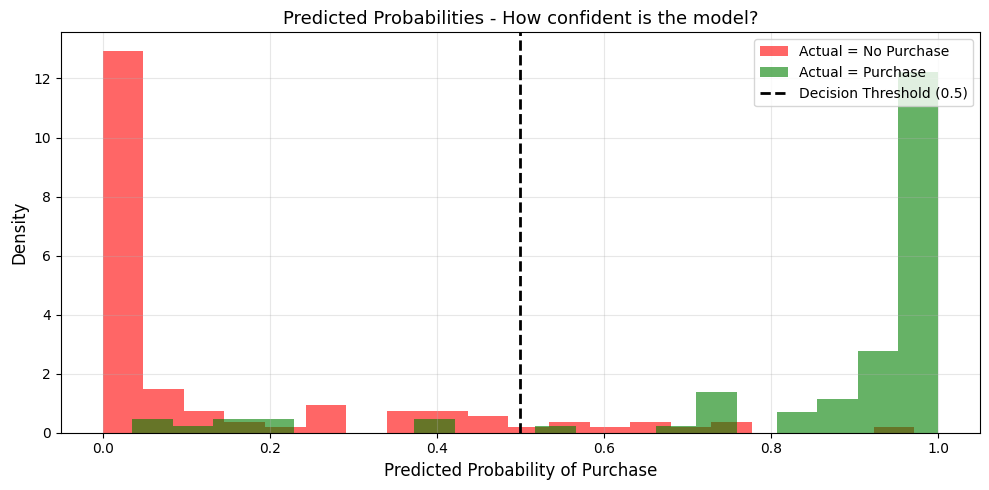


What we see:
Red = Actually did NOT purchase (should have low probability)
Green = Actually purchased (should have high probability)
Black line = Decision boundary (>=0.5 = Predict Purchase)

Good model: Green mostly on the right, Red mostly on the left!


In [15]:
# Plot distribution of predicted probabilities
plt.figure(figsize=(10, 5))

# Separate probabilities by actual class
prob_actual_0 = y_prob[y_test == 0]  # Probabilities for actual "No"
prob_actual_1 = y_prob[y_test == 1]  # Probabilities for actual "Yes"

# Histograms
plt.hist(prob_actual_0, bins=20, alpha=0.6, label='Actual = No Purchase', 
         color='red', density=True)
plt.hist(prob_actual_1, bins=20, alpha=0.6, label='Actual = Purchase', 
         color='green', density=True)

# Decision threshold line
plt.axvline(x=0.5, color='black', linestyle='--', linewidth=2, 
           label='Decision Threshold (0.5)')

plt.xlabel('Predicted Probability of Purchase', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Predicted Probabilities - How confident is the model?', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nWhat we see:")
print("Red = Actually did NOT purchase (should have low probability)")
print("Green = Actually purchased (should have high probability)")
print("Black line = Decision boundary (>=0.5 = Predict Purchase)")
print("\nGood model: Green mostly on the right, Red mostly on the left!")

In [16]:
# Create 5 new customers
new_customers = np.array([
    [30, 50, 2],   # Young, low income, few visits
    [45, 90, 7],   # Middle age, high income, many visits
    [25, 35, 1],   # Young, low income, rare visits
    [55, 120, 10], # Older, high income, many visits
    [35, 70, 4]    # Average customer
])

# Get probabilities
probabilities = model.predict_proba(new_customers)[:, 1]
predictions = model.predict(new_customers)

# Show results
print("NEW CUSTOMER PREDICTIONS")
print("="*60)
print(f"{'Age':>4} {'Income':>7} {'Visits':>7} {'Prob (%)':>10} {'Will Buy?':>12}")
print("-"*60)

for i, (customer, prob, pred) in enumerate(zip(new_customers, probabilities, predictions)):
    prob_pct = prob * 100
    will_buy = "YES" if pred == 1 else "NO"
    print(f"{customer[0]:>4} {customer[1]:>7} {customer[2]:>7} {prob_pct:>9.1f}% {will_buy:>12}")

print("\nHow it works:")
print("1. Model calculates z = m₁×Age + m₂×Income + m₃×Visits + c")
print("2. Converts z to probability using sigmoid: p = 1/(1+e^(-z))")
print("3. If p >= 0.5 → Predict 'Will Buy'")
print("4. If p < 0.5  → Predict 'Won't Buy'")

NEW CUSTOMER PREDICTIONS
 Age  Income  Visits   Prob (%)    Will Buy?
------------------------------------------------------------
  30      50       2     100.0%          YES
  45      90       7     100.0%          YES
  25      35       1     100.0%          YES
  55     120      10     100.0%          YES
  35      70       4     100.0%          YES

How it works:
1. Model calculates z = m₁×Age + m₂×Income + m₃×Visits + c
2. Converts z to probability using sigmoid: p = 1/(1+e^(-z))
3. If p >= 0.5 → Predict 'Will Buy'
4. If p < 0.5  → Predict 'Won't Buy'


In [17]:
print("UNDERSTANDING THE FORMULA")
print("="*60)

# Show the actual coefficients
coefs = model.coef_[0]
intercept = model.intercept_[0]

print("1. Linear equation (z):")
print(f"   z = {coefs[0]:.3f}×Age + {coefs[1]:.3f}×Income + {coefs[2]:.3f}×Visits + {intercept:.3f}")
print()

print("2. Sigmoid (Probability):")
print("   Probability = 1 / (1 + e^(-z))")
print()

print("3. Decision Rule:")
print("   If Probability >= 0.5 → Customer will BUY")
print("   If Probability < 0.5  → Customer will NOT buy")
print()

print("EXAMPLE CALCULATION:")
# Pick the first new customer
customer = new_customers[0]
z = coefs[0]*customer[0] + coefs[1]*customer[1] + coefs[2]*customer[2] + intercept
prob = 1 / (1 + np.exp(-z))

print(f"For customer: Age={customer[0]}, Income={customer[1]}, Visits={customer[2]}")
print(f"Step 1: z = {coefs[0]:.3f}×{customer[0]} + {coefs[1]:.3f}×{customer[1]} + {coefs[2]:.3f}×{customer[2]} + {intercept:.3f}")
print(f"Step 2: z = {z:.3f}")
print(f"Step 3: Probability = 1/(1+e^(-{z:.3f})) = {prob:.3f}")
print(f"Step 4: {prob:.3f} >= 0.5? {'YES' if prob >= 0.5 else 'NO'}")
print(f"Step 5: Predict = {' BUY' if prob >= 0.5 else ' NO BUY'}")

UNDERSTANDING THE FORMULA
1. Linear equation (z):
   z = 3.403×Age + 0.713×Income + 0.336×Visits + 0.098

2. Sigmoid (Probability):
   Probability = 1 / (1 + e^(-z))

3. Decision Rule:
   If Probability >= 0.5 → Customer will BUY
   If Probability < 0.5  → Customer will NOT buy

EXAMPLE CALCULATION:
For customer: Age=30, Income=50, Visits=2
Step 1: z = 3.403×30 + 0.713×50 + 0.336×2 + 0.098
Step 2: z = 138.499
Step 3: Probability = 1/(1+e^(-138.499)) = 1.000
Step 4: 1.000 >= 0.5? YES
Step 5: Predict =  BUY


## 🎯 LOGISTIC REGRESSION - SIMPLE SUMMARY

### **What it does:**
Predicts YES/NO answers using a probability

### **The Formula (2 steps):**

**Step 1:** Calculate z = (m₁×x₁) + (m₂×x₂) + ... + c
**Step 2:** Convert to probability using Sigmoid

### **Sigmoid Function:**

σ(z) = 1/(1+e^(-z))

- Always between 0 and 1
- z > 0 → p > 0.5 (predict YES)
- z < 0 → p < 0.5 (predict NO)

### **Key Metrics:**
| Metric | What it tells you | Good Value |
|--------|------------------|------------|
| Log-Loss | Prediction errors | Lower = Better |
| AUC | Separation power | >0.8 = Good |
| Accuracy | Overall correctness | >0.8 = Good |
| Confusion Matrix | Where it makes mistakes | Visual check |

### **When to use:**
- Spam detection
- Customer churn prediction
- Disease diagnosis
- Fraud detection
- Any YES/NO prediction problem!

### **Memory Trick:**